<h1>Chapter 4 - Text Classification</h1>
<i>Classifying text with both representative and generative models</i>

<a href="https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961"><img src="https://img.shields.io/badge/Buy%20the%20Book!-grey?logo=amazon"></a>
<a href="https://www.oreilly.com/library/view/hands-on-large-language/9781098150952/"><img src="https://img.shields.io/badge/O'Reilly-white.svg?logo=data:image/svg%2bxml;base64,PHN2ZyB3aWR0aD0iMzQiIGhlaWdodD0iMjciIHZpZXdCb3g9IjAgMCAzNCAyNyIgZmlsbD0ibm9uZSIgeG1sbnM9Imh0dHA6Ly93d3cudzMub3JnLzIwMDAvc3ZnIj4KPGNpcmNsZSBjeD0iMTMiIGN5PSIxNCIgcj0iMTEiIHN0cm9rZT0iI0Q0MDEwMSIgc3Ryb2tlLXdpZHRoPSI0Ii8+CjxjaXJjbGUgY3g9IjMwLjUiIGN5PSIzLjUiIHI9IjMuNSIgZmlsbD0iI0Q0MDEwMSIvPgo8L3N2Zz4K"></a>
<a href="https://github.com/HandsOnLLM/Hands-On-Large-Language-Models"><img src="https://img.shields.io/badge/GitHub%20Repository-black?logo=github"></a>
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HandsOnLLM/Hands-On-Large-Language-Models/blob/main/chapter04/Chapter%204%20-%20Text%20Classification.ipynb)

---

This notebook is for Chapter 4 of the [Hands-On Large Language Models](https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961) book by [Jay Alammar](https://www.linkedin.com/in/jalammar) and [Maarten Grootendorst](https://www.linkedin.com/in/mgrootendorst/).

---

<a href="https://www.amazon.com/Hands-Large-Language-Models-Understanding/dp/1098150961">
<img src="https://raw.githubusercontent.com/HandsOnLLM/Hands-On-Large-Language-Models/main/images/book_cover.png" width="350"/></a>

### [OPTIONAL] - Installing Packages on <img src="https://colab.google/static/images/icons/colab.png" width=100>


If you are viewing this notebook on Google Colab (or any other cloud vendor), you need to **uncomment and run** the following codeblock to install the dependencies for this chapter:

---

💡 **NOTE**: We will want to use a GPU to run the examples in this notebook. In Google Colab, go to
**Runtime > Change runtime type > Hardware accelerator > GPU > GPU type > T4**.

---


In [2]:
# %%capture
!pip install "transformers==4.41.2" "sentence-transformers==3.0.1" openai
!pip install -U datasets

  Using cached transformers-4.41.2-py3-none-any.whl.metadata (43 kB)
  Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.7 kB)
Using cached transformers-4.41.2-py3-none-any.whl (9.1 MB)
Using cached tokenizers-0.19.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.15.2
    Uninstalling tokenizers-0.15.2:
      Successfully uninstalled tokenizers-0.15.2
  Attempting uninstall: transformers
    Found existing installation: transformers 4.39.3
    Uninstalling transformers-4.39.3:
      Successfully uninstalled transformers-4.39.3


# **Data**

In [2]:
from datasets import load_dataset

# Load our data
data = load_dataset("rotten_tomatoes")
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1066
    })
})

In [4]:
print(f"Train Text are : { [text for text in data['train']['text']]}")
print(f"Train Labels are : {data['train']['label'][:5]}")

Train Text are : ['the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .', 'the gorgeously elaborate continuation of " the lord of the rings " trilogy is so huge that a column of words cannot adequately describe co-writer/director peter jackson\'s expanded vision of j . r . r . tolkien\'s middle-earth .', 'effective but too-tepid biopic', 'if you sometimes like to go to the movies to have fun , wasabi is a good place to start .', "emerges as something rare , an issue movie that's so honest and keenly observed that it doesn't feel like one .", 'the film provides some great insight into the neurotic mindset of all comics -- even those who have reached the absolute top of the game .', 'offers that rare combination of entertainment and education .', 'perhaps no picture ever made has more literally showed that the road to hell is paved with good intentions .', "steer

In [5]:
import pandas as pd

# Convert the train split to a pandas DataFrame
df_train = pd.DataFrame(data["train"])

df_train

,text,label
0,the rock is destined to be the 21st century's ...,1
1,"the gorgeously elaborate continuation of "" the...",1
2,effective but too-tepid biopic,1
3,if you sometimes like to go to the movies to h...,1
4,"emerges as something rare , an issue movie tha...",1
...,...,...
8525,any enjoyment will be hinge from a personal th...,0
8526,if legendary shlockmeister ed wood had ever ma...,0
8527,hardly a nuanced portrait of a young woman's b...,0
8528,"interminably bleak , to say nothing of boring .",0


In [6]:
print(df_train.head())
print(df_train.tail())
# Check the balance of positive vs negative reviews
print(df_train['label'].value_counts())

                                                text  label
0  the rock is destined to be the 21st century's ...      1
1  the gorgeously elaborate continuation of " the...      1
2                     effective but too-tepid biopic      1
3  if you sometimes like to go to the movies to h...      1
4  emerges as something rare , an issue movie tha...      1
                                                   text  label
8525  any enjoyment will be hinge from a personal th...      0
8526  if legendary shlockmeister ed wood had ever ma...      0
8527  hardly a nuanced portrait of a young woman's b...      0
8528    interminably bleak , to say nothing of boring .      0
8529  things really get weird , though not particula...      0
label
1    4265
0    4265
Name: count, dtype: int64


In [7]:
data["train"][0, -1]

{'text': ['the rock is destined to be the 21st century\'s new " conan " and that he\'s going to make a splash even greater than arnold schwarzenegger , jean-claud van damme or steven segal .',
  'things really get weird , though not particularly scary : the movie is all portent and no content .'],
 'label': [1, 0]}

# **Text Classification with Representation Models**

## **Using a Task-specific Model**

In [8]:
from transformers import pipeline

# Path to our HF model
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"

# Load model into pipeline
pipe = pipeline(
    model=model_path,
    tokenizer=model_path,
    return_all_scores=True,
    device="cuda:0"
)

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
/usr/local/lib/python3.12/dist-packages/transformers/pipelines/text_classification.py:104: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  war

In [9]:
import numpy as np
from tqdm import tqdm
from transformers.pipelines.pt_utils import KeyDataset

# Run inference
y_pred = []
for output in tqdm(pipe(KeyDataset(data["test"], "text")), total=len(data["test"])):
    negative_score = output[0]["score"]
    positive_score = output[2]["score"]
    assignment = np.argmax([negative_score, positive_score])
    y_pred.append(assignment)

100%|██████████| 1066/1066 [00:14<00:00, 75.88it/s]


In [7]:
from sklearn.metrics import classification_report

def evaluate_performance(y_true, y_pred):
    """Create and print the classification report"""
    performance = classification_report(
        y_true, y_pred,
        target_names=["Negative Review", "Positive Review"]
    )
    print(performance)

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [12]:
y_true = data["test"]["label"]
evaluate_performance(y_true, y_pred)

                 precision    recall  f1-score   support

Negative Review       0.76      0.88      0.81       533
Positive Review       0.86      0.72      0.78       533

       accuracy                           0.80      1066
      macro avg       0.81      0.80      0.80      1066
   weighted avg       0.81      0.80      0.80      1066



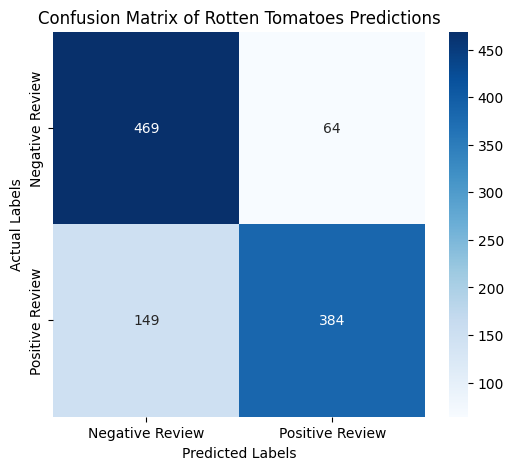

In [14]:
cm = confusion_matrix(y_true, y_pred)

# Plot using Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Negative Review", "Positive Review"],
            yticklabels=["Negative Review", "Positive Review"])
plt.ylabel('Actual Labels')
plt.xlabel('Predicted Labels')
plt.title('Confusion Matrix of Rotten Tomatoes Predictions')
plt.show()

In [13]:
import pandas as pd

# Create a DataFrame of our test results
analysis_df = pd.DataFrame({
    'text': data['test']['text'],
    'true_label': y_true,
    'pred_label': y_pred
})

# Filter out rows where the prediction didn't match the true label
mistakes = analysis_df[analysis_df['true_label'] != analysis_df['pred_label']]

print(f"Total misclassifications: {len(mistakes)} out of {len(y_true)}")

# Print 5 random mistakes to analyze them
for i, row in mistakes.sample(5).iterrows():
    print(f"\nReview: {row['text']}")
    print(f"Actual: {row['true_label']} | Predicted: {row['pred_label']}")
    print("-" * 50)

Total misclassifications: 213 out of 1066

Review: final verdict : you've seen it all before .
Actual: 0 | Predicted: 1
--------------------------------------------------

Review: there's a great deal of corny dialogue and preposterous moments . and yet , it still works .
Actual: 1 | Predicted: 0
--------------------------------------------------

Review: by the end of it all i sort of loved the people onscreen , even though i could not stand them . perhaps the film should be seen as a conversation starter . it's not an easy one to review .
Actual: 0 | Predicted: 1
--------------------------------------------------

Review: those who don't entirely 'get' godard's distinctive discourse will still come away with a sense of his reserved but existential poignancy .
Actual: 1 | Predicted: 0
--------------------------------------------------

Review: by the time it ends in a rush of sequins , flashbulbs , blaring brass and back-stabbing babes , it has said plenty about how show business has 

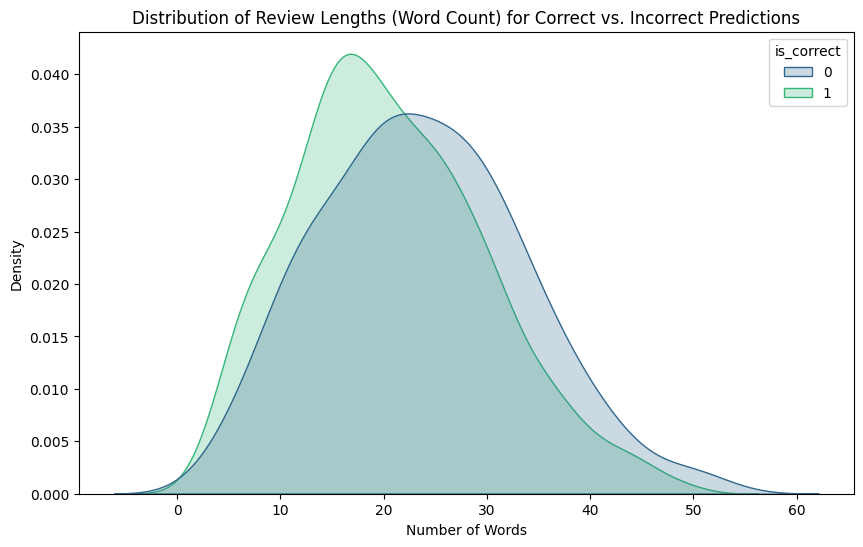

In [15]:
import numpy as np

# Calculate word counts for each review in the test set
analysis_df['word_count'] = analysis_df['text'].apply(lambda x: len(x.split()))
# Mark if the prediction was correct (1) or incorrect (0)
analysis_df['is_correct'] = (analysis_df['true_label'] == analysis_df['pred_label']).astype(int)

# Plot the distribution of word lengths for correct vs incorrect predictions
plt.figure(figsize=(10, 6))
sns.kdeplot(data=analysis_df, x='word_count', hue='is_correct', fill=True, common_norm=False, palette='viridis')
plt.title('Distribution of Review Lengths (Word Count) for Correct vs. Incorrect Predictions')
plt.xlabel('Number of Words')
plt.ylabel('Density')
plt.show()

In [16]:
# Grab the mistakes that are longer than 35 words to see what went wrong
long_mistakes = mistakes[mistakes['text'].apply(lambda x: len(x.split())) > 35]

# Print a couple to read them yourself
for i, row in long_mistakes.head(3).iterrows():
    print(f"Review: {row['text']}\n")

Review: you needn't be steeped in '50s sociology , pop culture or movie lore to appreciate the emotional depth of haynes' work . though haynes' style apes films from the period . . . its message is not rooted in that decade .

Review: the film has a laundry list of minor shortcomings , but the numerous scenes of gory mayhem are worth the price of admission . . . if " gory mayhem " is your idea of a good time .

Review: skin of man gets a few cheap shocks from its kids-in-peril theatrics , but it also taps into the primal fears of young people trying to cope with the mysterious and brutal nature of adults .



## **Classification Tasks that Leverage Embeddings**

In [18]:
!pip install "peft<=0.11.0" "transformers==4.41.2" "sentence-transformers==3.0.1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.2/251.2 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.19.1
    Uninstalling peft-0.19.1:
      Successfully uninstalled peft-0.19.1


### Supervised Classification

In [3]:
from sentence_transformers import SentenceTransformer

# Load model
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

# Convert text to embeddings
train_embeddings = model.encode(data["train"]["text"], show_progress_bar=True)
test_embeddings = model.encode(data["test"]["text"], show_progress_bar=True)

Batches:   0%|          | 0/267 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

In [4]:
train_embeddings.shape

(8530, 768)

In [5]:
from sklearn.linear_model import LogisticRegression

# Train a Logistic Regression on our train embeddings
clf = LogisticRegression(random_state=42)
clf.fit(train_embeddings, data["train"]["label"])

LogisticRegression(random_state=42)

In [8]:
# Predict previously unseen instances
y_pred = clf.predict(test_embeddings)
evaluate_performance(data["test"]["label"], y_pred)

                 precision    recall  f1-score   support

Negative Review       0.85      0.86      0.85       533
Positive Review       0.86      0.85      0.85       533

       accuracy                           0.85      1066
      macro avg       0.85      0.85      0.85      1066
   weighted avg       0.85      0.85      0.85      1066



**Tip!**  

What would happen if we would not use a classifier at all? Instead, we can average the embeddings per class and apply cosine similarity to predict which classes match the documents best:

In [9]:
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report
from sklearn.metrics.pairwise import cosine_similarity

# Average the embeddings of all documents in each target label
df = pd.DataFrame(np.hstack([train_embeddings, np.array(data["train"]["label"]).reshape(-1, 1)]))
averaged_target_embeddings = df.groupby(768).mean().values

# Find the best matching embeddings between evaluation documents and target embeddings
sim_matrix = cosine_similarity(test_embeddings, averaged_target_embeddings)
y_pred = np.argmax(sim_matrix, axis=1)

# Evaluate the model
evaluate_performance(data["test"]["label"], y_pred)

                 precision    recall  f1-score   support

Negative Review       0.85      0.84      0.84       533
Positive Review       0.84      0.85      0.84       533

       accuracy                           0.84      1066
      macro avg       0.84      0.84      0.84      1066
   weighted avg       0.84      0.84      0.84      1066



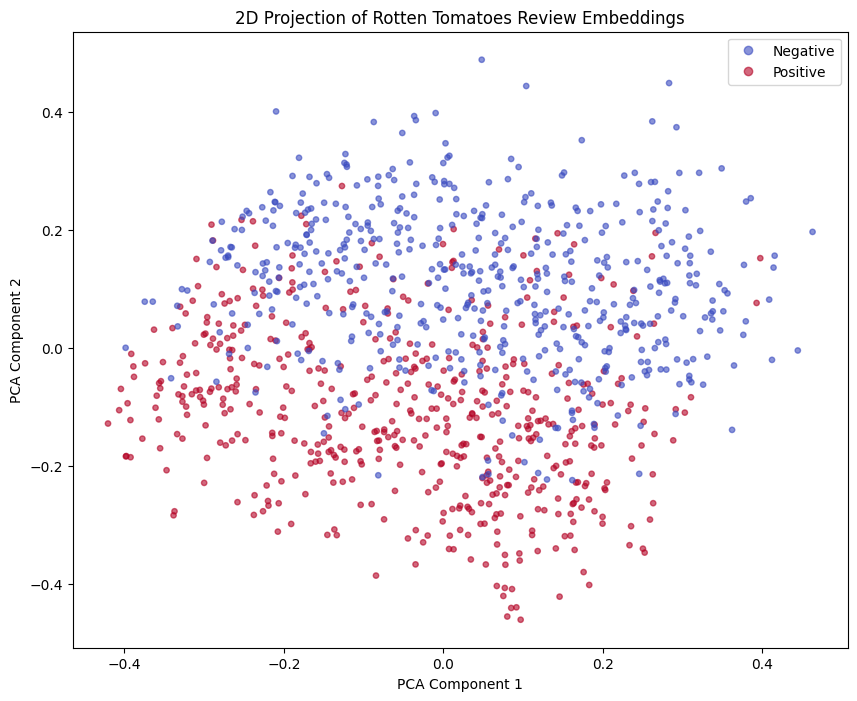

In [23]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# or from sklearn.manifold import TSNE

# Compress the test embeddings down to 2 dimensions
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(test_embeddings)

# Plot the 2D points, coloring them by their actual label
plt.figure(figsize=(10, 8))
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=data["test"]["label"], cmap='coolwarm', alpha=0.6, s=15)

plt.legend(handles=scatter.legend_elements()[0], labels=["Negative", "Positive"])
plt.title("2D Projection of Rotten Tomatoes Review Embeddings")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

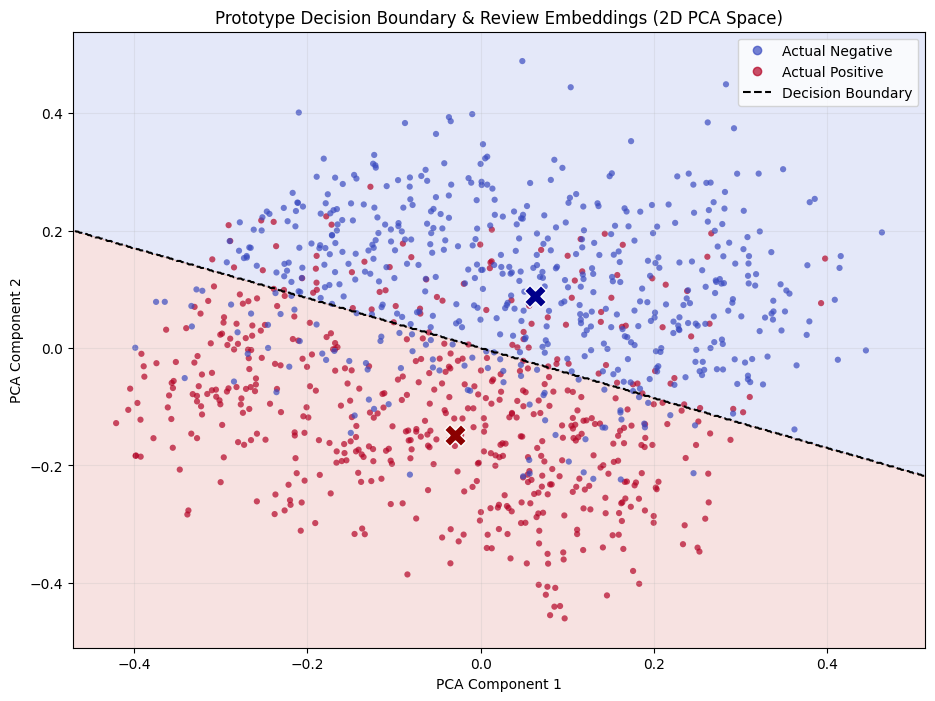

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

# 1. Compress the test embeddings down to 2 dimensions
pca = PCA(n_components=2, random_state=42)
embeddings_2d = pca.fit_transform(test_embeddings)

# 2. Compress the 768D prototypes into the exact same 2D PCA space
# (averaged_target_embeddings has shape [2, 768])
prototypes_2d = pca.transform(averaged_target_embeddings)
neg_prototype_2d = prototypes_2d[0]
pos_prototype_2d = prototypes_2d[1]

# 3. Create a mesh grid over the boundaries of our 2D plot
x_min, x_max = embeddings_2d[:, 0].min() - 0.05, embeddings_2d[:, 0].max() + 0.05
y_min, y_max = embeddings_2d[:, 1].min() - 0.05, embeddings_2d[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.002),
                     np.arange(y_min, y_max, 0.002))

# 4. Flatten the grid points to calculate similarities for the entire background
grid_points = np.c_[xx.ravel(), yy.ravel()]

# Calculate cosine similarity of every grid coordinate to the 2D prototypes
grid_sims = cosine_similarity(grid_points, prototypes_2d)
# Determine background assignment (0 or 1) based on argmax
grid_predictions = np.argmax(grid_sims, axis=1)
grid_predictions = grid_predictions.reshape(xx.shape)

# 5. Start plotting
plt.figure(figsize=(11, 8))

# Draw the decision boundary / background regions
plt.contourf(xx, yy, grid_predictions, alpha=0.15, cmap='coolwarm')
# Draw the explicit boundary line separating the two regions
plt.contour(xx, yy, grid_predictions, levels=[0.5], colors='black', linewidths=1.5, linestyles='--')

# Plot the test data points colored by their ACTUAL labels
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                      c=data["test"]["label"], cmap='coolwarm', alpha=0.7, s=20, edgecolors='none')

# Plot the central Prototypes as large distinct markers so you can see them
plt.scatter(neg_prototype_2d[0], neg_prototype_2d[1], color='darkblue', marker='X', s=250, label='Negative Centroid', edgecolor='white')
plt.scatter(pos_prototype_2d[0], pos_prototype_2d[1], color='darkred', marker='X', s=250, label='Positive Centroid', edgecolor='white')

# Aesthetics and Labels
labels = ["Actual Negative", "Actual Positive"]
legend_handles = scatter.legend_elements()[0]
plt.legend(handles=legend_handles + [plt.Line2D([0], [0], color='black', linestyle='--')],
           labels=labels + ["Decision Boundary"], loc="upper right")

plt.title("Prototype Decision Boundary & Review Embeddings (2D PCA Space)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.grid(True, alpha=0.2)
plt.show()

In [29]:
# Type any phrase—even if those exact words don't exist in the reviews!
search_query = "an absolute cinematic masterpiece that blew me away"
query_embedding = model.encode([search_query])

# Calculate similarity between your query and all test reviews
search_sims = cosine_similarity(query_embedding, test_embeddings)[0]

# Get the indices of the top 3 most similar reviews
top_indices = np.argsort(search_sims)[-3:][::-1]

print(f"Query: '{search_query}'\n")
for idx in top_indices:
    print(f"Score: {search_sims[idx]:.4f} | Label: {data['test']['label'][idx]}")
    print(f"Review: {data['test']['text'][idx]}\n")


Query: 'an absolute cinematic masterpiece that blew me away'

Score: 0.6644 | Label: 1
Review: a movie of technical skill and rare depth of intellect and feeling .

Score: 0.6601 | Label: 1
Review: nothing short of a masterpiece -- and a challenging one .

Score: 0.6494 | Label: 1
Review: this is a shrewd and effective film from a director who understands how to create and sustain a mood .



In [12]:
# sim_matrix[:, 0] is similarity to Negative Prototype
# sim_matrix[:, 1] is similarity to Positive Prototype

most_negative_idx = np.argmax(sim_matrix[:, 0])
most_positive_idx = np.argmax(sim_matrix[:, 1])

print("--- THE DEFINITIVE NEGATIVE REVIEW ---")
print(data["test"]["text"][most_negative_idx])

print("\n--- THE DEFINITIVE POSITIVE REVIEW ---")
print(data["test"]["text"][most_positive_idx])

--- THE DEFINITIVE NEGATIVE REVIEW ---
purports to be a hollywood satire but winds up as the kind of film that should be the target of something deeper and more engaging . oh , and more entertaining , too .

--- THE DEFINITIVE POSITIVE REVIEW ---
. it's a testament to the film's considerable charm that it succeeds in entertaining , despite playing out like a feature-length sitcom replete with stereotypical familial quandaries . there's a sheer unbridled delight in the way the story unfurls . . .


In [21]:
# Grab a tiny slice of the data
tiny_train = data["train"].shuffle(seed=42).select(range(50)) # 50 random samples
test = data["test"]

# Convert text to embeddings
tiny_train_embeddings = model.encode(tiny_train["text"], show_progress_bar=True)
test_embeddings = model.encode(test["text"], show_progress_bar=True)

# Average the embeddings of all documents in each target label
df = pd.DataFrame(np.hstack([tiny_train_embeddings, np.array(tiny_train["label"]).reshape(-1, 1)]))
averaged_target_embeddings = df.groupby(768).mean().values

# Find the best matching embeddings between evaluation documents and target embeddings
sim_matrix = cosine_similarity(test_embeddings, averaged_target_embeddings)
y_pred = np.argmax(sim_matrix, axis=1)

# Evaluate the model
evaluate_performance(test["label"], y_pred)

Batches:   0%|          | 0/2 [00:00<?, ?it/s]

Batches:   0%|          | 0/34 [00:00<?, ?it/s]

                 precision    recall  f1-score   support

Negative Review       0.80      0.82      0.81       533
Positive Review       0.81      0.79      0.80       533

       accuracy                           0.81      1066
      macro avg       0.81      0.81      0.81      1066
   weighted avg       0.81      0.81      0.81      1066



In [22]:
# Calculate the absolute difference between the two similarity scores
sim_difference = np.abs(sim_matrix[:, 0] - sim_matrix[:, 1])

# Find the index of the smallest difference (closest to the middle boundary)
most_confusing_idx = np.argmin(sim_difference)

print("--- THE MOST AMBIGUOUS/NEUTRAL REVIEW ---")
print(data["test"]["text"][most_confusing_idx])

--- THE MOST AMBIGUOUS/NEUTRAL REVIEW ---
" . . . something appears to have been lost in the translation this time . the importance of being earnest movie seems to be missing a great deal of the acerbic repartee of the play . "


### Zero-shot Classification

In [ ]:
# Create embeddings for our labels
label_embeddings = model.encode(["A negative review",  "A positive review"])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Find the best matching label for each document
sim_matrix = cosine_similarity(test_embeddings, label_embeddings)
y_pred = np.argmax(sim_matrix, axis=1)

In [ ]:
evaluate_performance(data["test"]["label"], y_pred)

                 precision    recall  f1-score   support

Negative Review       0.78      0.77      0.78       533
Positive Review       0.77      0.79      0.78       533

       accuracy                           0.78      1066
      macro avg       0.78      0.78      0.78      1066
   weighted avg       0.78      0.78      0.78      1066



**Tip!**  

What would happen if you were to use different descriptions? Use **"A very negative movie review"** and **"A very positive movie review"** to see what happens!

## **Classification with Generative Models**

### Encoder-decoder Models

In [ ]:
# Load our model
pipe = pipeline(
    "text2text-generation",
    model="google/flan-t5-small",
    device="cuda:0"
)

In [ ]:
# Prepare our data
prompt = "Is the following sentence positive or negative? "
data = data.map(lambda example: {"t5": prompt + example['text']})
data

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 't5'],
        num_rows: 8530
    })
    validation: Dataset({
        features: ['text', 'label', 't5'],
        num_rows: 1066
    })
    test: Dataset({
        features: ['text', 'label', 't5'],
        num_rows: 1066
    })
})

In [ ]:
# Run inference
y_pred = []
for output in tqdm(pipe(KeyDataset(data["test"], "t5")), total=len(data["test"])):
    text = output[0]["generated_text"]
    y_pred.append(0 if text == "negative" else 1)


  0%|          | 0/1066 [00:00<?, ?it/s]/usr/local/lib/python3.10/dist-packages/transformers/generation/utils.py:1178: UserWarning: Using the model-agnostic default `max_length` (=20) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
100%|██████████| 1066/1066 [00:40<00:00, 26.07it/s]


In [ ]:
evaluate_performance(data["test"]["label"], y_pred)

                 precision    recall  f1-score   support

Negative Review       0.83      0.85      0.84       533
Positive Review       0.85      0.83      0.84       533

       accuracy                           0.84      1066
      macro avg       0.84      0.84      0.84      1066
   weighted avg       0.84      0.84      0.84      1066



### ChatGPT for Classification

In [ ]:
import openai

# Create client
client = openai.OpenAI(api_key="YOUR_KEY_HERE")

In [ ]:
def chatgpt_generation(prompt, document, model="gpt-3.5-turbo-0125"):
    """Generate an output based on a prompt and an input document."""
    messages=[
        {
            "role": "system",
            "content": "You are a helpful assistant."
            },
        {
            "role": "user",
            "content":   prompt.replace("[DOCUMENT]", document)
            }
    ]
    chat_completion = client.chat.completions.create(
      messages=messages,
      model=model,
      temperature=0
    )
    return chat_completion.choices[0].message.content

In [ ]:
# Define a prompt template as a base
prompt = """Predict whether the following document is a positive or negative movie review:

[DOCUMENT]

If it is positive return 1 and if it is negative return 0. Do not give any other answers.
"""

# Predict the target using GPT
document = "unpretentious , charming , quirky , original"
chatgpt_generation(prompt, document)

'1'

The next step would be to run one of OpenAI's model against the entire evaluation dataset. However, only run this when you have sufficient tokens as this will call the API for the entire test dataset (1066 records).

In [ ]:
# You can skip this if you want to save your (free) credits
predictions = [chatgpt_generation(prompt, doc) for doc in tqdm(data["test"]["text"])]

100%|██████████| 1066/1066 [13:34<00:00,  1.31it/s]


In [ ]:
# Extract predictions
y_pred = [int(pred) for pred in predictions]

# Evaluate performance
evaluate_performance(data["test"]["label"], y_pred)

                 precision    recall  f1-score   support

Negative Review       0.87      0.97      0.92       533
Positive Review       0.96      0.86      0.91       533

       accuracy                           0.91      1066
      macro avg       0.92      0.91      0.91      1066
   weighted avg       0.92      0.91      0.91      1066

